<a href="https://colab.research.google.com/github/rajthakur5/CNN-from-scratch-MNIST/blob/main/cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reduce size for faster training (important for scratch CNN)
x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(2000, 28, 28)


In [ ]:
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

def softmax(x):
    exp = np.exp(x - np.max(x))
    return exp / np.sum(exp)

def cross_entropy(pred, label):
    return -np.log(pred[label] + 1e-9)

In [ ]:
class Conv2D:
    def __init__(self, num_filters, filter_size):
        self.num_filters = num_filters
        self.filter_size = filter_size
        self.filters = np.random.randn(num_filters, filter_size, filter_size) / 9

    def forward(self, input):
        self.input = input
        h, w = input.shape
        output = np.zeros((h - 2, w - 2, self.num_filters))

        for i in range(h - 2):
            for j in range(w - 2):
                region = input[i:i+3, j:j+3]
                for f in range(self.num_filters):
                    output[i, j, f] = np.sum(region * self.filters[f])
        return output

    def backward(self, dL_dout, lr):
        dL_dfilters = np.zeros(self.filters.shape)

        for i in range(self.input.shape[0] - 2):
            for j in range(self.input.shape[1] - 2):
                region = self.input[i:i+3, j:j+3]
                for f in range(self.num_filters):
                    dL_dfilters[f] += dL_dout[i, j, f] * region

        self.filters -= lr * dL_dfilters
        return None

In [ ]:
class ReLU:
    def forward(self, input):
        self.input = input
        return np.maximum(0, input)

    def backward(self, dL_dout):
        return dL_dout * (self.input > 0)

In [ ]:
class MaxPool:
    def forward(self, input):
        self.input = input
        h, w, f = input.shape
        output = np.zeros((h//2, w//2, f))

        for i in range(0, h, 2):
            for j in range(0, w, 2):
                region = input[i:i+2, j:j+2]
                output[i//2, j//2] = np.max(region, axis=(0,1))
        return output

    def backward(self, dL_dout):
        dL_dinput = np.zeros(self.input.shape)
        h, w, f = self.input.shape

        for i in range(0, h, 2):
            for j in range(0, w, 2):
                region = self.input[i:i+2, j:j+2]
                max_val = np.max(region, axis=(0,1))

                for x in range(2):
                    for y in range(2):
                        for k in range(f):
                            if region[x, y, k] == max_val[k]:
                                dL_dinput[i+x, j+y, k] = dL_dout[i//2, j//2, k]
        return dL_dinput

In [ ]:
class Dense:
    def __init__(self, input_len, output_len):
        self.weights = np.random.randn(input_len, output_len) / input_len
        self.bias = np.zeros(output_len)

    def forward(self, input):
        self.input = input.flatten()
        return np.dot(self.input, self.weights) + self.bias

    def backward(self, dL_dout, lr):
        dL_dw = np.outer(self.input, dL_dout)
        dL_db = dL_dout

        self.weights -= lr * dL_dw
        self.bias -= lr * dL_db

In [ ]:
conv = Conv2D(8, 3)      # 8 filters
relu = ReLU()
pool = MaxPool()
fc = Dense(13*13*8, 10)

In [ ]:
def train(image, label, lr=0.005):
    # Forward
    out = conv.forward(image)
    out = relu.forward(out)
    out = pool.forward(out)
    out = fc.forward(out)

    probs = softmax(out)
    loss = cross_entropy(probs, label)

    # Accuracy
    acc = 1 if np.argmax(probs) == label else 0

    # Backward
    grad = probs
    grad[label] -= 1

    fc.backward(grad, lr)

    return loss, acc

In [ ]:
epochs = 3

for epoch in range(epochs):
    loss = 0
    correct = 0

    for i in range(len(x_train)):
        l, acc = train(x_train[i], y_train[i])
        loss += l
        correct += acc

        if i % 200 == 0:
            print(f"Step {i}: Loss {loss/(i+1):.3f} | Acc {correct/(i+1):.3f}")

    print(f"Epoch {epoch+1} Completed")

Step 0: Loss 2.302 | Acc 0.000
Step 200: Loss 2.225 | Acc 0.299
Step 400: Loss 2.139 | Acc 0.499
Step 600: Loss 2.079 | Acc 0.549
Step 800: Loss 2.025 | Acc 0.578
Step 1000: Loss 1.967 | Acc 0.614
Step 1200: Loss 1.920 | Acc 0.631
Step 1400: Loss 1.876 | Acc 0.643
Step 1600: Loss 1.832 | Acc 0.658
Step 1800: Loss 1.774 | Acc 0.677
Epoch 1 Completed
Step 0: Loss 1.677 | Acc 0.000
Step 200: Loss 1.262 | Acc 0.836
Step 400: Loss 1.190 | Acc 0.838
Step 600: Loss 1.200 | Acc 0.824
Step 800: Loss 1.199 | Acc 0.815
Step 1000: Loss 1.185 | Acc 0.814
Step 1200: Loss 1.183 | Acc 0.808
Step 1400: Loss 1.173 | Acc 0.804
Step 1600: Loss 1.157 | Acc 0.808
Step 1800: Loss 1.125 | Acc 0.818
Epoch 2 Completed
Step 0: Loss 1.311 | Acc 0.000
Step 200: Loss 0.922 | Acc 0.851
Step 400: Loss 0.857 | Acc 0.860
Step 600: Loss 0.881 | Acc 0.845
Step 800: Loss 0.895 | Acc 0.840
Step 1000: Loss 0.895 | Acc 0.838
Step 1200: Loss 0.905 | Acc 0.831
Step 1400: Loss 0.904 | Acc 0.829
Step 1600: Loss 0.894 | Acc 0.833

In [ ]:
correct = 0

for i in range(len(x_test)):
    out = conv.forward(x_test[i])
    out = relu.forward(out)
    out = pool.forward(out)
    out = fc.forward(out)

    if np.argmax(out) == y_test[i]:
        correct += 1

print("Test Accuracy:", correct / len(x_test))

Test Accuracy: 0.816


In [ ]:
def predict(image):
    out = conv.forward(image)
    out = relu.forward(out)
    out = pool.forward(out)
    out = fc.forward(out)
    return softmax(out)

Final Test Accuracy: 0.816


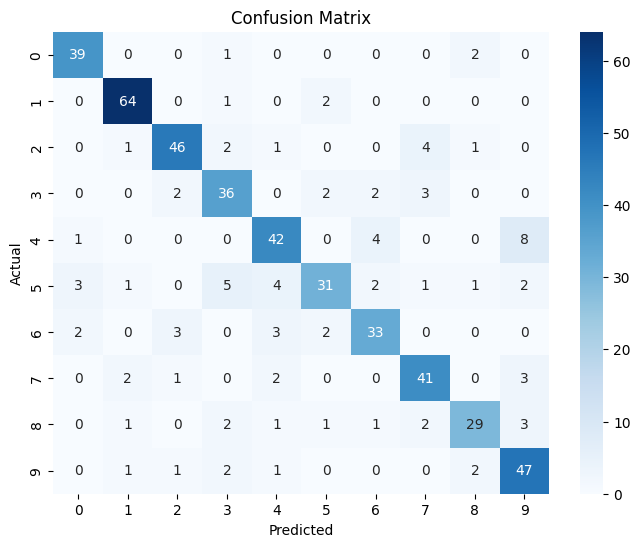

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.91      0.96      0.93        67
           2       0.87      0.84      0.85        55
           3       0.73      0.80      0.77        45
           4       0.78      0.76      0.77        55
           5       0.82      0.62      0.70        50
           6       0.79      0.77      0.78        43
           7       0.80      0.84      0.82        49
           8       0.83      0.72      0.77        40
           9       0.75      0.87      0.80        54

    accuracy                           0.82       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.82      0.82      0.81       500



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = []

for i in range(len(x_test)):
    probs = predict(x_test[i])
    y_pred.append(np.argmax(probs))

# Accuracy
accuracy = np.mean(np.array(y_pred) == y_test)
print("Final Test Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

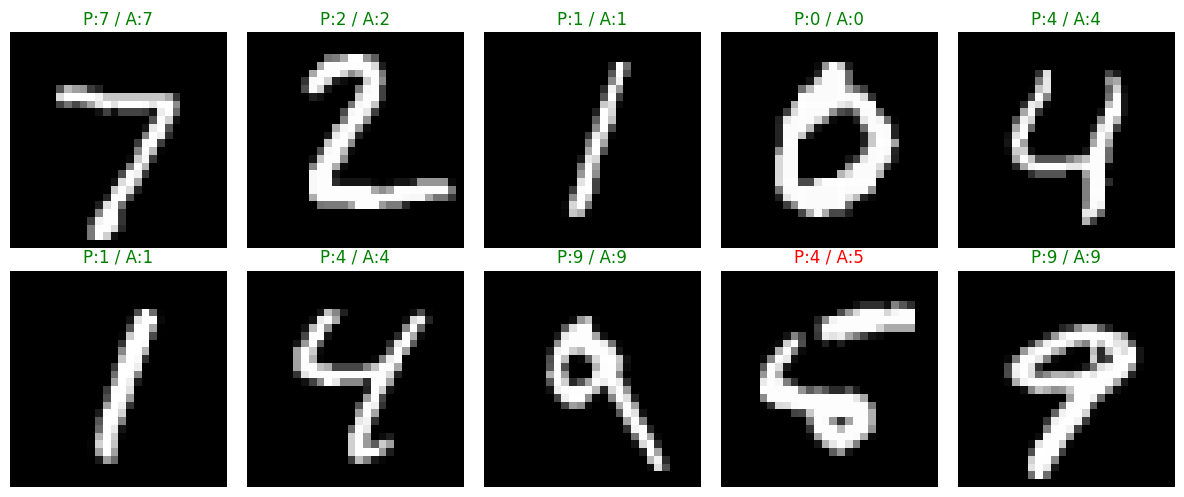

In [ ]:
def plot_predictions(n=10):
    plt.figure(figsize=(12,5))

    for i in range(n):
        plt.subplot(2,5,i+1)
        plt.imshow(x_test[i], cmap='gray')

        probs = predict(x_test[i])
        pred = np.argmax(probs)
        actual = y_test[i]

        color = "green" if pred == actual else "red"

        plt.title(f"P:{pred} / A:{actual}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_predictions(10)

In [ ]:
loss_list = []
acc_list = []

epochs = 3

for epoch in range(epochs):
    loss = 0
    correct = 0

    for i in range(len(x_train)):
        l, acc = train(x_train[i], y_train[i])
        loss += l
        correct += acc

    loss_list.append(loss / len(x_train))
    acc_list.append(correct / len(x_train))

    print(f"Epoch {epoch+1}: Loss {loss_list[-1]:.3f}, Accuracy {acc_list[-1]:.3f}")

Epoch 1: Loss 0.730, Accuracy 0.854
Epoch 2: Loss 0.651, Accuracy 0.863
Epoch 3: Loss 0.597, Accuracy 0.871


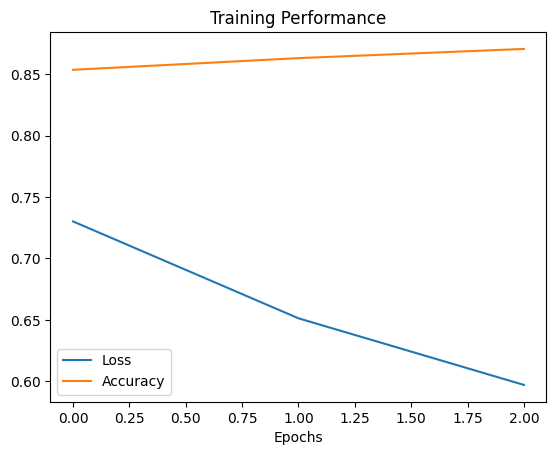

In [ ]:
plt.plot(loss_list, label="Loss")
plt.plot(acc_list, label="Accuracy")
plt.legend()
plt.title("Training Performance")
plt.xlabel("Epochs")
plt.show()